# Bodrum Hotel & Destination Intelligence
## 18 - Google Travel × Trip.com Cross-Platform Customer Voice Analysis

Kural (E3): review satırları birebir merge edilmez; karşılaştırma hotel/aspect özet seviyesindedir.

In [1]:

import sys
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import os

from bodrum_intelligence.analysis.aspect_dictionary import detect_aspects, ASPECT_KEYWORDS
from bodrum_intelligence.analysis.cross_platform import agreement_flag, support_flag, hotel_coverage, rating_gap

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\cross_platform"
os.makedirs(FIG_DIR, exist_ok=True)

google = pd.read_csv(REPO_ROOT + r"\data\processed\google_travel_all_hotels_reviews_clean.csv")
trip = pd.read_csv(REPO_ROOT + r"\data\processed\tripcom_reviews_clean.csv")
print("google rows:", len(google), "| trip rows:", len(trip))


google rows: 2336 | trip rows: 3013


## E2: Common hotel set

In [2]:

g_hotels = set(google["hotel_id"].unique())
t_hotels = set(trip["hotel_id"].unique())
cov = hotel_coverage(g_hotels, t_hotels)
common, google_only, trip_only = cov["both"], cov["google_only"], cov["trip_only"]

coverage_rows = (
    [{"hotel_id": h, "coverage": "BOTH"} for h in common] +
    [{"hotel_id": h, "coverage": "GOOGLE_ONLY"} for h in google_only] +
    [{"hotel_id": h, "coverage": "TRIP_ONLY"} for h in trip_only]
)
coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(REPO_ROOT + r"\reports\cross_platform_hotel_coverage.csv", index=False)
print(f"common={len(common)} google_only={len(google_only)} trip_only={len(trip_only)}")


common=58 google_only=46 trip_only=36


## E4-E5: Hotel x source rating summary (normalized to 5-scale)

In [3]:

g_stats = google.groupby("hotel_id").agg(
    google_n=("review_rating_numeric","count"), google_mean=("review_rating_numeric","mean"),
    google_median=("review_rating_numeric","median"),
)
g_stats["google_low_share"] = google.groupby("hotel_id").apply(lambda d: (d["rating_group"]=="LOW").mean(), include_groups=False)
g_stats["google_high_share"] = google.groupby("hotel_id").apply(lambda d: (d["rating_group"]=="HIGH").mean(), include_groups=False)

t_stats = trip.groupby("hotel_id").agg(
    trip_n=("rating_5_scale","count"), trip_mean_5=("rating_5_scale","mean"),
    trip_median_5=("rating_5_scale","median"),
)
t_stats["trip_low_share"] = trip.groupby("hotel_id").apply(lambda d: (d["rating_group"]=="LOW").mean(), include_groups=False)
t_stats["trip_high_share"] = trip.groupby("hotel_id").apply(lambda d: (d["rating_group"]=="HIGH").mean(), include_groups=False)

rating_compare = pd.DataFrame({"hotel_id": common}).set_index("hotel_id").join([g_stats, t_stats]).reset_index()
rating_compare["rating_gap_mean"] = rating_compare.apply(
    lambda r: rating_gap(r["google_mean"], r["trip_mean_5"]), axis=1)
rating_compare["rating_gap_median"] = rating_compare.apply(
    lambda r: rating_gap(r["google_median"], r["trip_median_5"]), axis=1)
rating_compare.to_csv(REPO_ROOT + r"\reports\cross_platform_rating_comparison.csv", index=False)
rating_compare[["rating_gap_mean","rating_gap_median"]].to_csv(REPO_ROOT + r"\reports\cross_platform_rating_gap.csv", index=False)
rating_compare.head(10)


,hotel_id,google_n,google_mean,google_median,google_low_share,google_high_share,trip_n,trip_mean_5,trip_median_5,trip_low_share,trip_high_share,rating_gap_mean,rating_gap_median
0,BOD002,10.0,3.600000,4.0,0.200000,0.600000,11.0,3.818182,5.0,0.272727,0.727273,-0.218,-1.0
1,BOD003,30.0,4.433333,5.0,0.133333,0.833333,28.0,3.678571,4.0,0.214286,0.678571,0.755,1.0
2,BOD004,10.0,2.000000,1.0,0.700000,0.300000,11.0,3.954545,5.0,0.181818,0.636364,-1.955,-4.0
3,BOD007,60.0,4.066667,5.0,0.183333,0.733333,11.0,4.259091,4.6,0.090909,0.818182,-0.192,0.4
4,BOD008,20.0,5.000000,5.0,0.000000,1.000000,11.0,4.009091,5.0,0.181818,0.727273,0.991,0.0
5,BOD010,10.0,3.200000,3.5,0.300000,0.500000,2.0,4.000000,4.0,0.000000,1.000000,-0.800,-0.5
6,BOD011,10.0,4.800000,5.0,0.000000,0.900000,11.0,4.750000,5.0,0.000000,0.818182,0.050,0.0
7,BOD012,10.0,4.100000,5.0,0.200000,0.800000,11.0,4.613636,5.0,0.090909,0.818182,-0.514,0.0
8,BOD013,72.0,4.027778,5.0,0.180556,0.750000,8.0,4.375000,5.0,0.125000,0.875000,-0.347,0.0
9,BOD014,10.0,4.600000,5.0,0.100000,0.900000,11.0,3.545455,4.0,0.272727,0.636364,1.055,1.0


## E6-E7: Agreement / disagreement flag (explicit threshold)
Kural: |rating_gap_mean| <= 0.3 -> HIGH_AGREEMENT, 0.3-0.7 -> MODERATE_AGREEMENT, > 0.7 -> DISAGREEMENT.
Bu bir gap sinyalidir; hangi platformun "doğru" olduğunu göstermez.

In [4]:

rating_compare["agreement"] = rating_compare["rating_gap_mean"].apply(
    lambda g: agreement_flag(None if pd.isna(g) else g))
rating_compare["agreement"].value_counts()


agreement
HIGH_AGREEMENT        24
DISAGREEMENT          17
MODERATE_AGREEMENT    17
Name: count, dtype: int64

## E8: Sample-size aware support flag

In [5]:

rating_compare["comparison_support"] = rating_compare.apply(
    lambda r: support_flag(r["google_n"], r["trip_n"]), axis=1)
rating_compare[["hotel_id","google_n","trip_n","comparison_support"]].to_csv(
    REPO_ROOT + r"\reports\cross_platform_sample_support.csv", index=False)
# re-save with agreement + comparison_support included (both computed after the first save)
rating_compare.to_csv(REPO_ROOT + r"\reports\cross_platform_rating_comparison.csv", index=False)
rating_compare["comparison_support"].value_counts()


comparison_support
SUPPORTED_COMPARISON    54
LOW_SUPPORT              4
Name: count, dtype: int64

## E16 (partial): Google vs Trip rating scatter

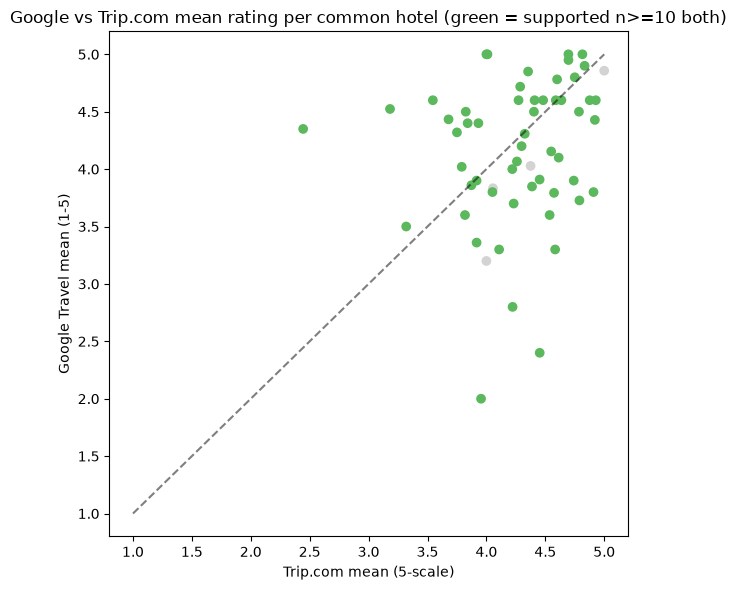

In [6]:

supported = rating_compare[rating_compare["comparison_support"]=="SUPPORTED_COMPARISON"]
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rating_compare["trip_mean_5"], rating_compare["google_mean"],
           c=(rating_compare["comparison_support"]=="SUPPORTED_COMPARISON").map({True:"#5cb85c", False:"#d3d3d3"}))
lims = [1, 5]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel("Trip.com mean (5-scale)"); ax.set_ylabel("Google Travel mean (1-5)")
ax.set_title("Google vs Trip.com mean rating per common hotel (green = supported n>=10 both)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\google_vs_trip_rating_scatter.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Her nokta ortak bir oteldir; x=Trip.com ortalaması, y=Google Travel ortalaması, kesikli çizgi tam uyumu gösterir.
### Ne görüyoruz?
İki platformun aynı otel için ne kadar benzer/farklı puanladığı.
### Neden önemli?
Platformlar arası sistematik sapma olup olmadığını gösterir.
### Dikkat edilmesi gereken nokta
Gri noktalar (n<10 herhangi bir platformda) düşük güvenilirliktedir; yalnız yeşil noktalar SUPPORTED_COMPARISON'dur.

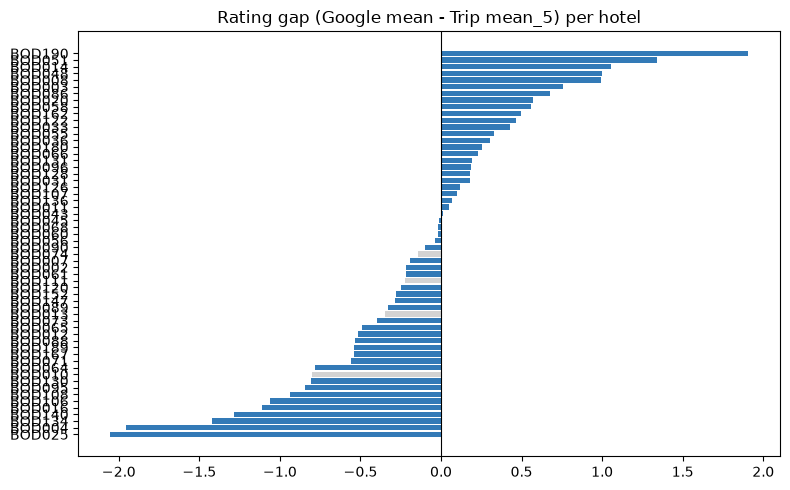

In [7]:

fig, ax = plt.subplots(figsize=(8,5))
sorted_gap = rating_compare.sort_values("rating_gap_mean")
colors = sorted_gap["comparison_support"].map({"SUPPORTED_COMPARISON":"#337ab7","LOW_SUPPORT":"#d3d3d3"})
ax.barh(sorted_gap["hotel_id"], sorted_gap["rating_gap_mean"], color=colors)
ax.axvline(0, color="k", linewidth=0.8)
ax.set_title("Rating gap (Google mean - Trip mean_5) per hotel")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\rating_gap_by_hotel.png", dpi=110)
plt.show()


## E9: Review length comparison

In [8]:

google["word_count"] = google["review_text_clean"].fillna("").str.split().apply(len)
trip["word_count"] = trip["review_text_clean"].fillna("").str.split().apply(len)
length_compare = pd.DataFrame([{
    "google_median_words": google["word_count"].median(),
    "trip_median_words": trip["word_count"].median(),
}])
length_compare.to_csv(REPO_ROOT + r"\reports\cross_platform_review_length.csv", index=False)
length_compare


,google_median_words,trip_median_words
0,44.0,37.0


## E12-E13: Google aspect taxonomy applied to Trip text too

In [9]:

trip["aspects"] = trip["review_text_clean"].apply(lambda t: detect_aspects(t) if isinstance(t, str) else set())
google["aspects"] = google["review_text_clean"].apply(lambda t: detect_aspects(t) if isinstance(t, str) else set())

rows = []
for hotel_id in common:
    g = google[google["hotel_id"]==hotel_id]
    t = trip[trip["hotel_id"]==hotel_id]
    for aspect in ASPECT_KEYWORDS:
        g_mask = g["aspects"].apply(lambda s: aspect in s)
        t_mask = t["aspects"].apply(lambda s: aspect in s)
        g_rate = round(g_mask.mean()*100, 1) if len(g) else None
        t_rate = round(t_mask.mean()*100, 1) if len(t) else None
        g_low = round(g.loc[g_mask, "rating_group"].eq("LOW").mean()*100, 1) if g_mask.sum() else None
        t_low = round(t.loc[t_mask, "rating_group"].eq("LOW").mean()*100, 1) if t_mask.sum() else None
        if g_mask.sum() == 0 and t_mask.sum() == 0:
            continue
        if g_mask.sum() >= 3 and t_mask.sum() >= 3:
            consistency = "BOTH_SOURCE_SIGNAL"
        elif g_mask.sum() >= 3:
            consistency = "GOOGLE_ONLY_SIGNAL"
        elif t_mask.sum() >= 3:
            consistency = "TRIP_ONLY_SIGNAL"
        else:
            consistency = "LOW_SUPPORT"
        rows.append({"hotel_id": hotel_id, "aspect": aspect, "google_mention_rate": g_rate,
                      "google_low_context_share": g_low, "trip_mention_rate": t_rate,
                      "trip_low_context_share": t_low, "consistency": consistency})
aspect_consistency = pd.DataFrame(rows)
aspect_consistency.to_csv(REPO_ROOT + r"\reports\cross_platform_aspect_consistency.csv", index=False)
aspect_consistency["consistency"].value_counts()


consistency
GOOGLE_ONLY_SIGNAL    489
LOW_SUPPORT           324
BOTH_SOURCE_SIGNAL    298
TRIP_ONLY_SIGNAL       56
Name: count, dtype: int64

## E16: Aspect consistency heatmap (overall, aggregated across hotels)

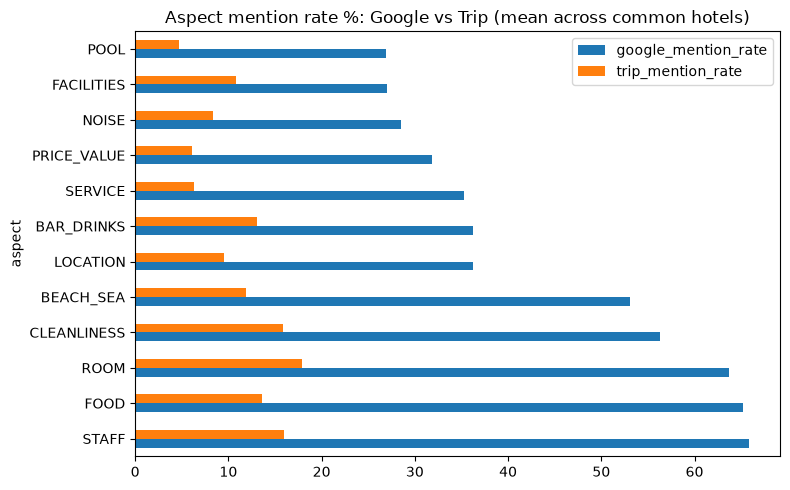

In [10]:

overall_aspect = aspect_consistency.groupby("aspect").agg(
    google_mention_rate=("google_mention_rate","mean"), trip_mention_rate=("trip_mention_rate","mean"),
).dropna(how="all")
if len(overall_aspect):
    fig, ax = plt.subplots(figsize=(8,5))
    overall_aspect.sort_values("google_mention_rate", ascending=False).head(12).plot(kind="barh", ax=ax)
    ax.set_title("Aspect mention rate %: Google vs Trip (mean across common hotels)")
    plt.tight_layout()
    plt.savefig(FIG_DIR + r"\aspect_consistency_comparison.png", dpi=110)
    plt.show()


### Grafik nasıl okunur?
Her aspect için Google ve Trip korpuslarındaki ortalama bahsedilme oranı yan yana.
### Ne görüyoruz?
Hangi konuların her iki platformda da tutarlı şekilde öne çıktığı.
### Neden önemli?
BOTH_SOURCE_SIGNAL olan bulgular, tek platforma dayalı bulgulardan daha güvenilirdir.
### Dikkat edilmesi gereken nokta
Trip.com korpusu küçük olduğundan (bkz coverage), çoğu aspect LOW_SUPPORT/GOOGLE_ONLY_SIGNAL olabilir.

## E17: Notebook 18 - Final Answers

In [11]:

answers = {}
answers["common_hotels"] = len(common)
answers["supported_comparison_hotels"] = int((rating_compare["comparison_support"]=="SUPPORTED_COMPARISON").sum())
answers["overall_mean_diff"] = round(rating_compare["rating_gap_mean"].mean(), 3) if len(rating_compare) else None
biggest = rating_compare.reindex(rating_compare["rating_gap_mean"].abs().sort_values(ascending=False).index).head(3)
answers["largest_divergences"] = biggest[["hotel_id","rating_gap_mean","comparison_support"]].to_dict("records")
answers["agreement_dist"] = rating_compare["agreement"].value_counts().to_dict()
answers["review_length_behavior"] = length_compare.to_dict("records")[0] if len(length_compare) else None
answers["aspect_consistency_dist"] = aspect_consistency["consistency"].value_counts().to_dict() if len(aspect_consistency) else {}
answers["main_limitations"] = [
    "Trip.com sample is much smaller than Google's - most comparisons are LOW_SUPPORT",
    "No row-level merge; comparisons are hotel/aspect-summary level only",
    "Rating gap is a divergence signal, not a truth judgment",
    "Different sampling mechanisms per platform (section 3)",
]
for k, v in answers.items():
    print(f"{k}: {v}")

with open(REPO_ROOT + r"\reports\cross_platform_key_findings.txt", "w", encoding="utf-8") as f:
    for k, v in answers.items():
        f.write(f"{k}: {v}\n")


common_hotels: 58
supported_comparison_hotels: 54
overall_mean_diff: -0.118
largest_divergences: [{'hotel_id': 'BOD025', 'rating_gap_mean': -2.052, 'comparison_support': 'SUPPORTED_COMPARISON'}, {'hotel_id': 'BOD004', 'rating_gap_mean': -1.955, 'comparison_support': 'SUPPORTED_COMPARISON'}, {'hotel_id': 'BOD190', 'rating_gap_mean': 1.906, 'comparison_support': 'SUPPORTED_COMPARISON'}]
agreement_dist: {'HIGH_AGREEMENT': 24, 'DISAGREEMENT': 17, 'MODERATE_AGREEMENT': 17}
review_length_behavior: {'google_median_words': 44.0, 'trip_median_words': 37.0}
aspect_consistency_dist: {'GOOGLE_ONLY_SIGNAL': 489, 'LOW_SUPPORT': 324, 'BOTH_SOURCE_SIGNAL': 298, 'TRIP_ONLY_SIGNAL': 56}
main_limitations: ["Trip.com sample is much smaller than Google's - most comparisons are LOW_SUPPORT", 'No row-level merge; comparisons are hotel/aspect-summary level only', 'Rating gap is a divergence signal, not a truth judgment', 'Different sampling mechanisms per platform (section 3)']
